<a href="https://www.kaggle.com/code/sonawanelalitsunil/energy-efficiency-data-ml-99-84?scriptVersionId=233277337" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/energy-efficiency-dataset/ENB2012_data.csv


### Title: Energy Efficiency Data

### Description: Dataset containing building features and energy performance metrics used to analyze heating and cooling load efficiency.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/energy-efficiency-dataset/ENB2012_data.csv')

In [3]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [5]:
df.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
763,0.64,784.0,343.0,220.5,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.5,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.5,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.5,3.5,4,0.4,5,16.48,16.61
767,0.62,808.5,367.5,220.5,3.5,5,0.4,5,16.64,16.03


In [6]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [7]:
df.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

In [8]:
df.shape

(768, 10)

In [9]:
df.dtypes

X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object

In [10]:
df. duplicated().sum()

0

In [11]:
df. isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

In [12]:
df.shape

(768, 10)

In [13]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

## Data visualizations

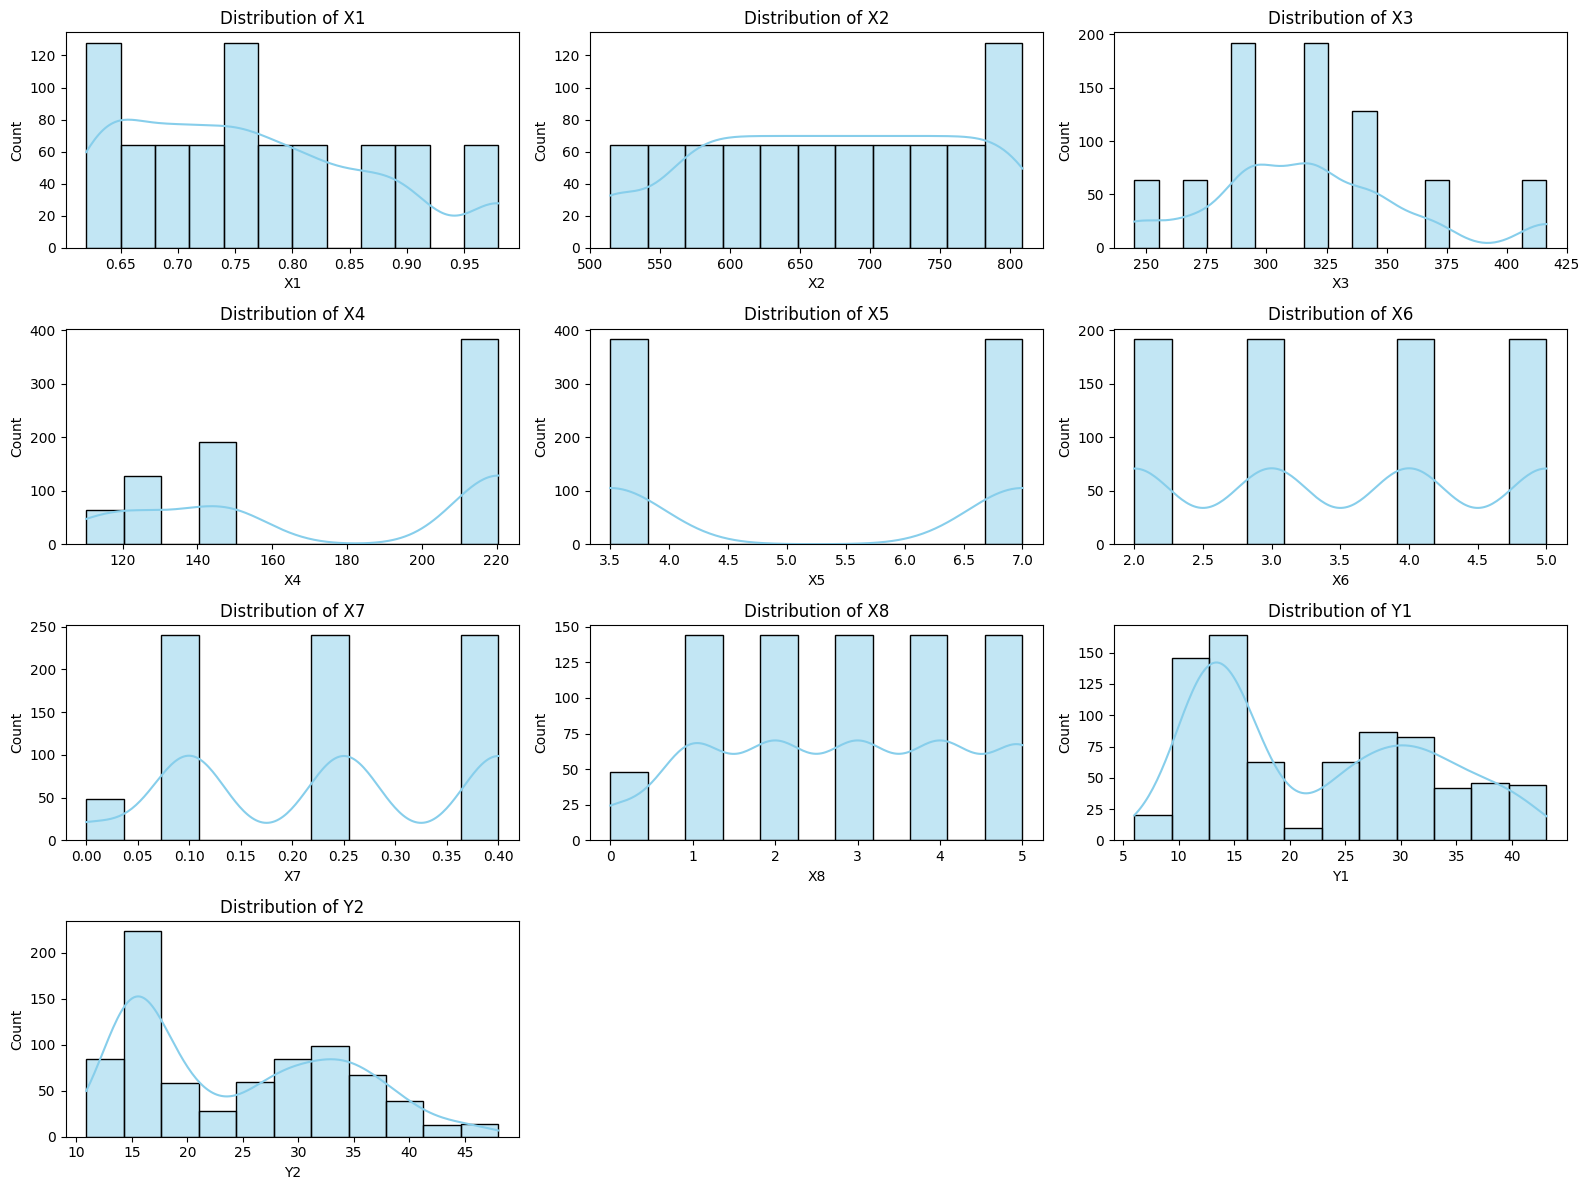

In [14]:
features = df.columns
plt.figure(figsize=(16, 12))
for i, col in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

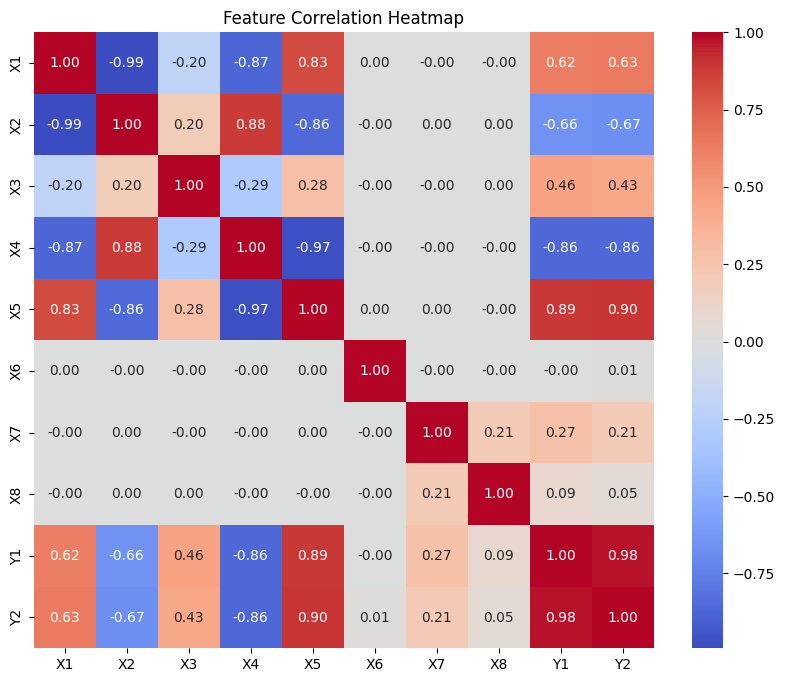

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

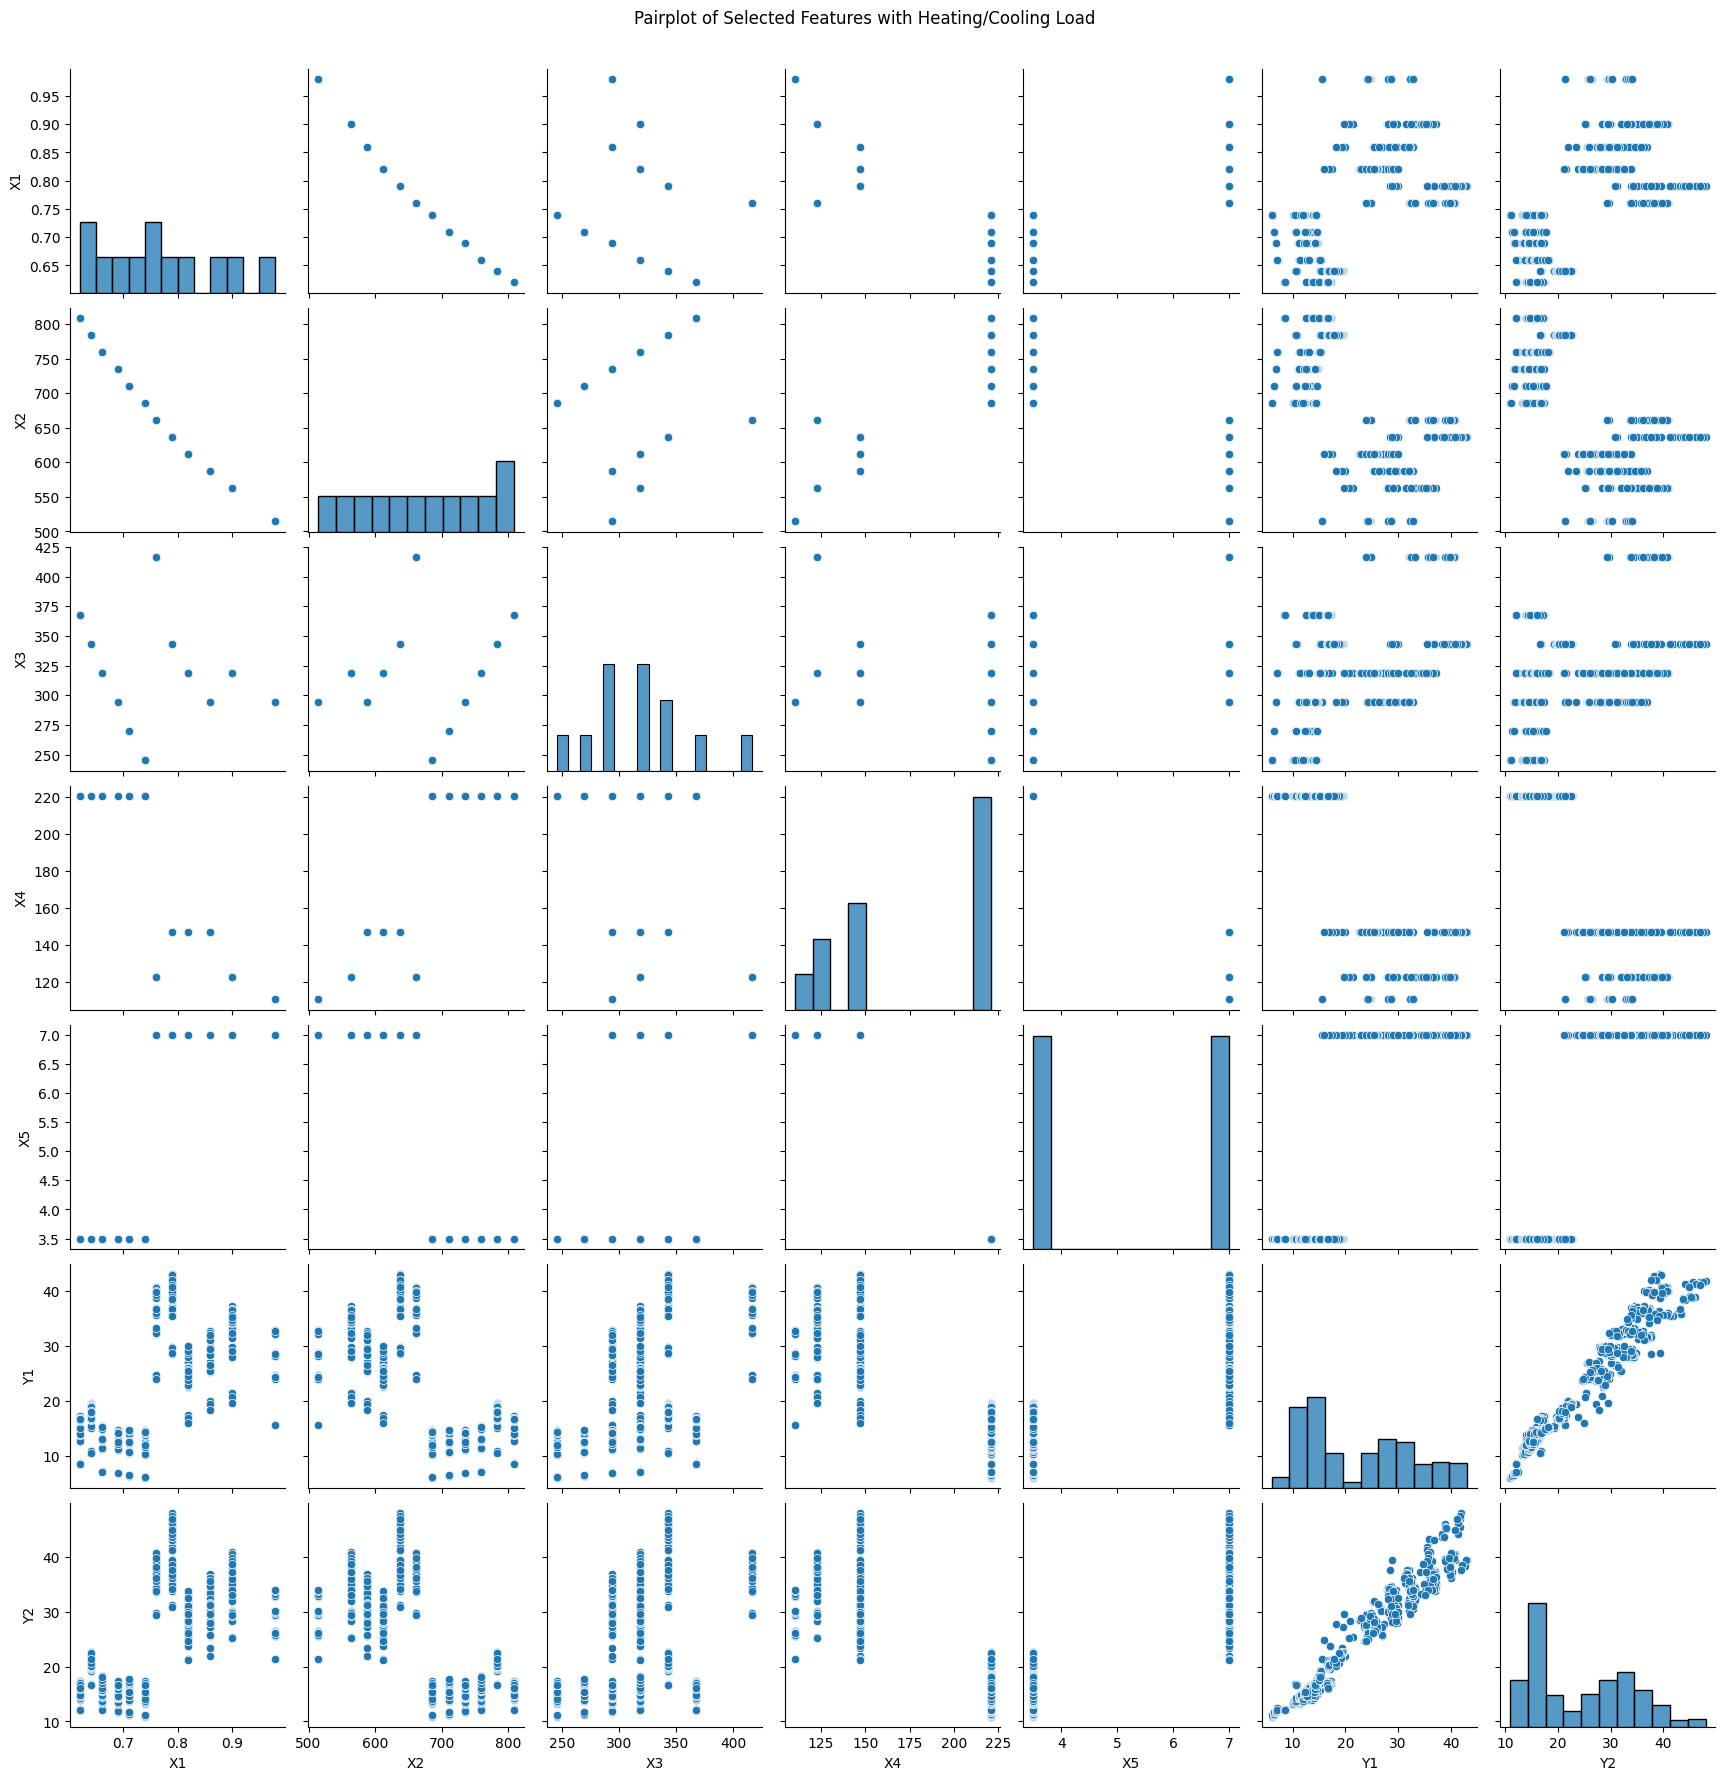

In [16]:
sns.pairplot(df[['X1', 'X2', 'X3', 'X4', 'X5', 'Y1', 'Y2']])
plt.suptitle('Pairplot of Selected Features with Heating/Cooling Load', y=1.02)
plt.show()


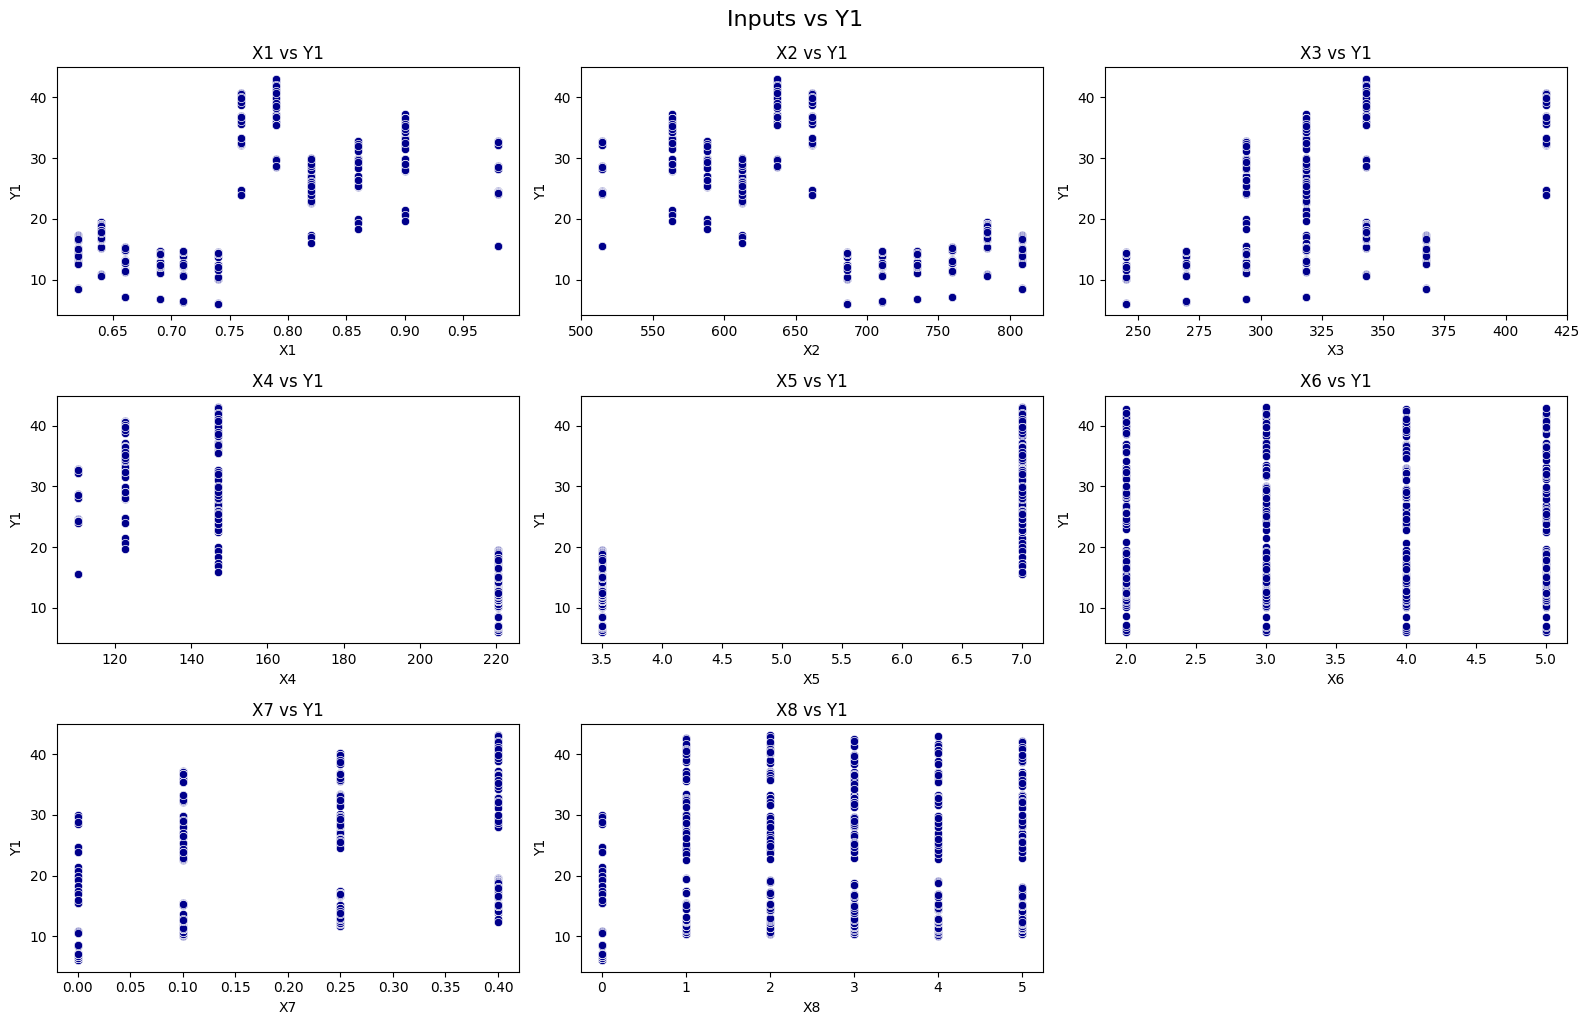

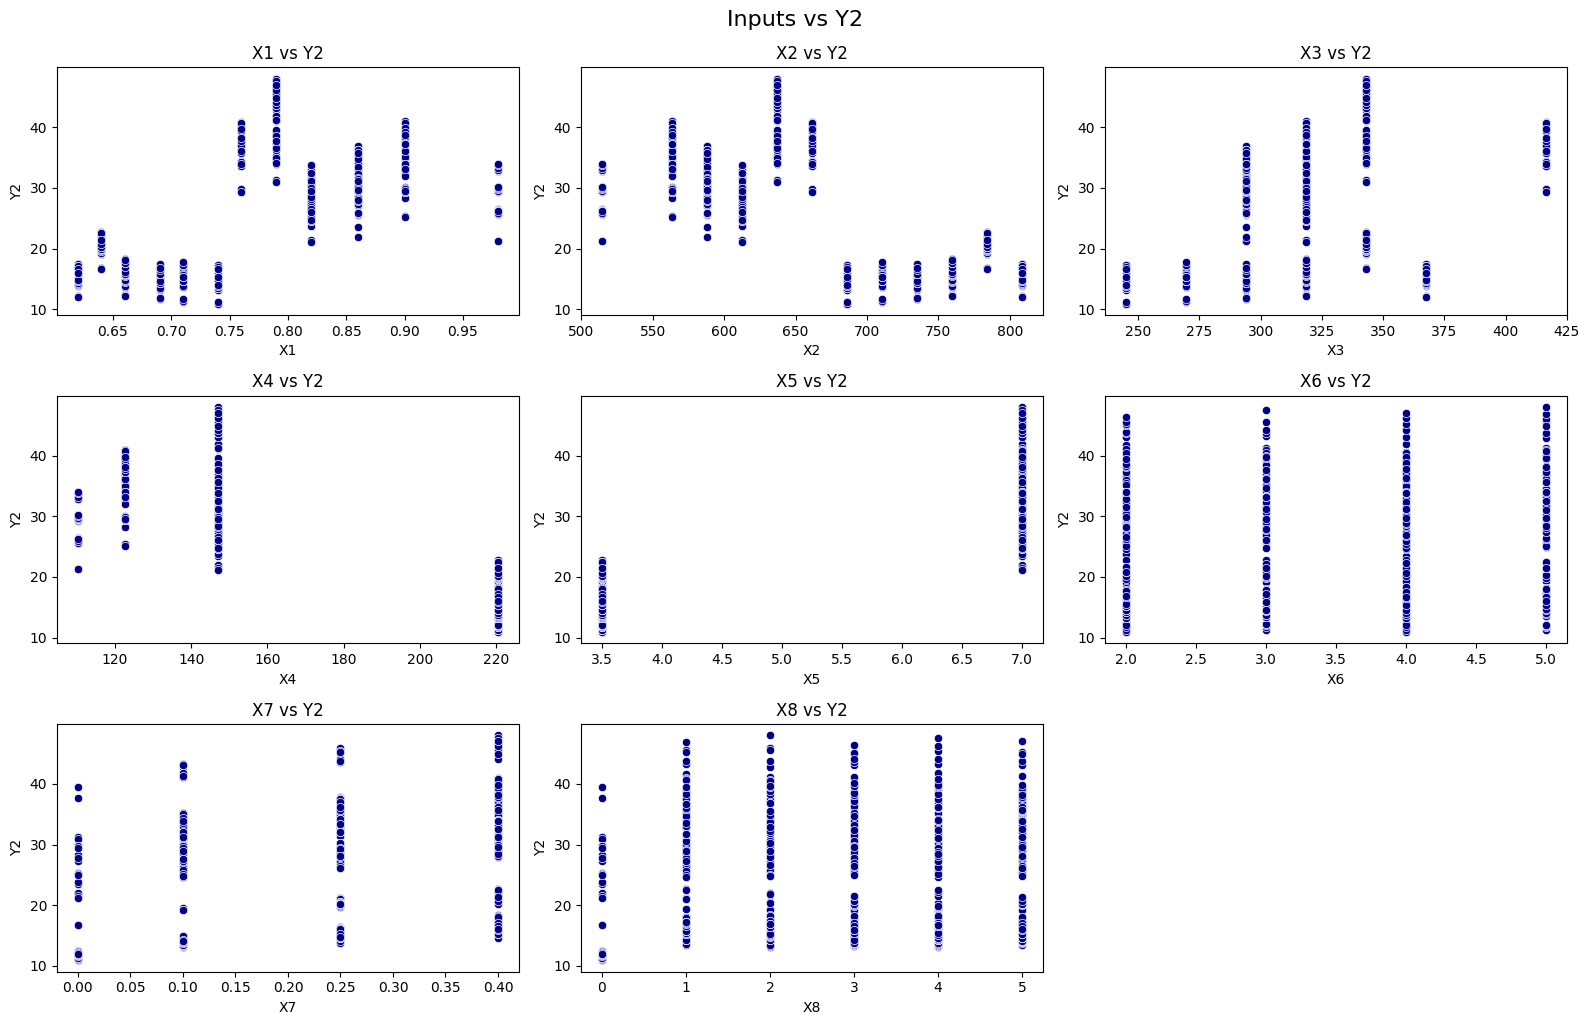

In [17]:
target_cols = ['Y1', 'Y2']
input_cols = [col for col in df.columns if col not in target_cols]

for y in target_cols:
    plt.figure(figsize=(16, 10))
    for i, x in enumerate(input_cols):
        plt.subplot(3, 3, i+1)
        sns.scatterplot(x=df[x], y=df[y], color='darkblue')
        plt.title(f'{x} vs {y}')
    plt.tight_layout()
    plt.suptitle(f'Inputs vs {y}', fontsize=16, y=1.02)
    plt.show()


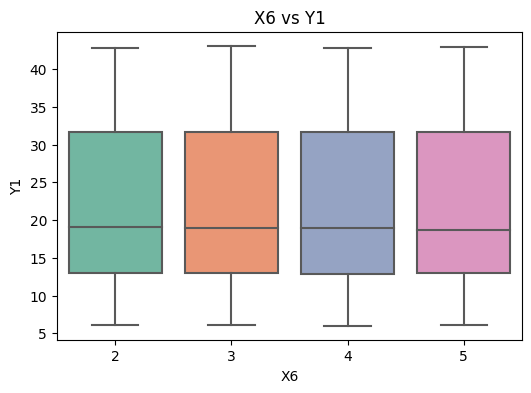

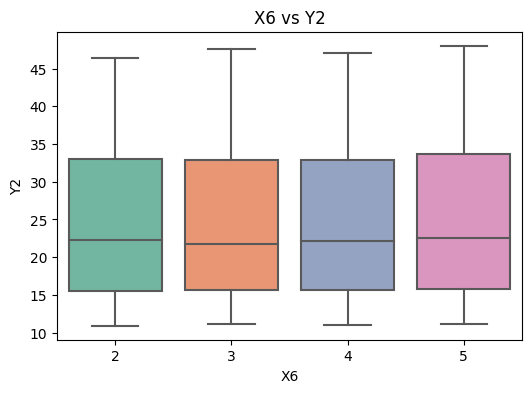

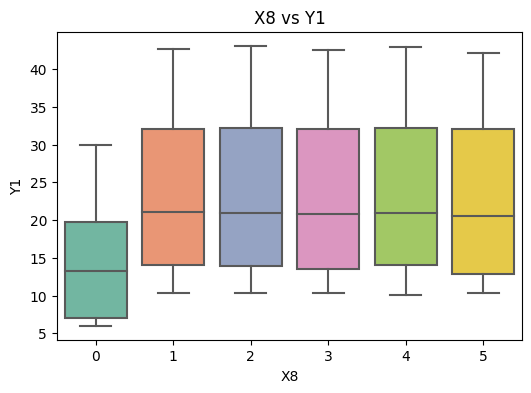

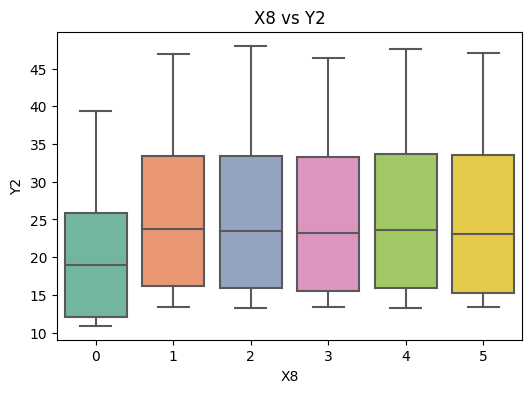

In [18]:
categorical_cols = ['X6', 'X8']
for cat in categorical_cols:
    for y in ['Y1', 'Y2']:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[cat], y=df[y], palette='Set2')
        plt.title(f'{cat} vs {y}')
        plt.show()


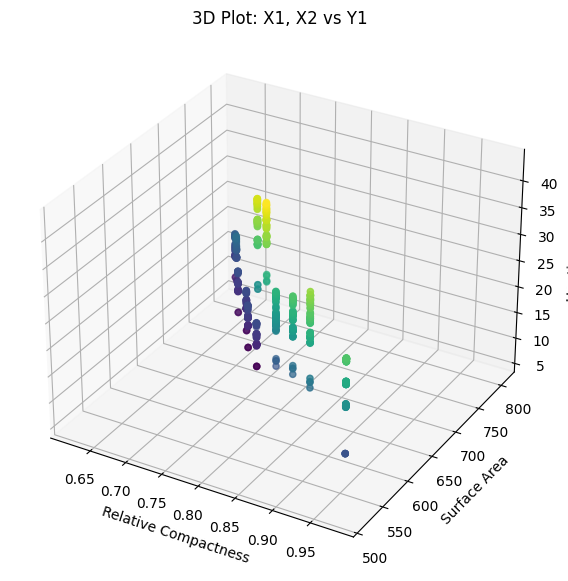

In [19]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['X1'], df['X2'], df['Y1'], c=df['Y1'], cmap='viridis')
ax.set_xlabel('Relative Compactness')
ax.set_ylabel('Surface Area')
ax.set_zlabel('Heating Load')
plt.title('3D Plot: X1, X2 vs Y1')
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# ML models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [21]:
label_cols = ['X6', 'X8']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [22]:
X = df.drop(['Y1', 'Y2'], axis=1)
y = df['Y1']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor(),
    'XGBoost': XGBRegressor(verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor()
}

In [25]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred) * 100  # R² score as percentage
    results[name] = round(score, 2)
    

In [26]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy (R² %)'])
print(results_df.sort_values(by='Accuracy (R² %)', ascending=False))

               Model  Accuracy (R² %)
5            XGBoost            99.84
1      Random Forest            99.77
6  Gradient Boosting            99.75
3      Decision Tree            99.63
4                KNN            95.34
0  Linear Regression            91.20
2                SVR            69.31


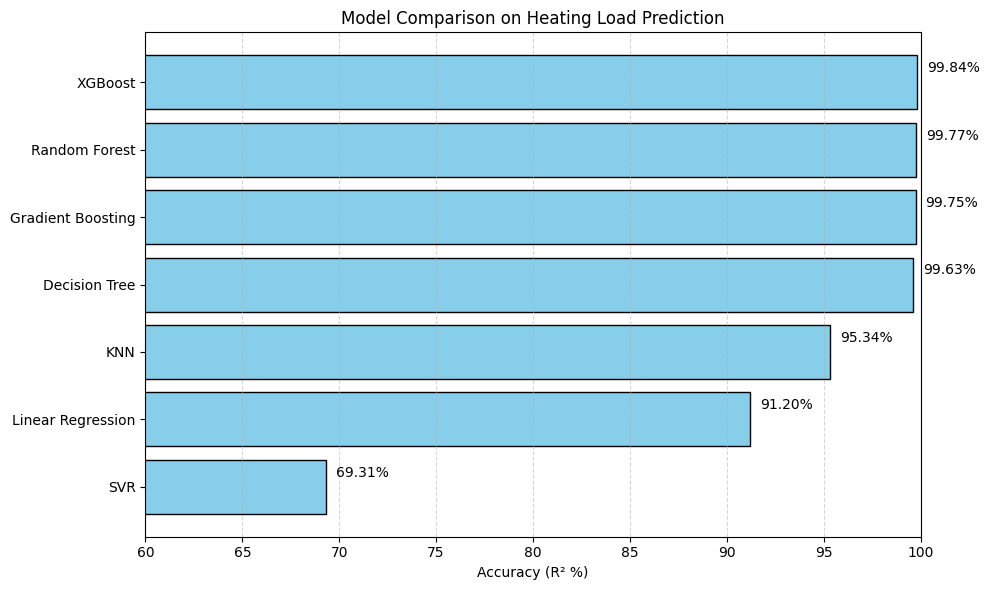

In [27]:
models = ['XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree', 'KNN', 'Linear Regression', 'SVR']
accuracy = [99.84, 99.77, 99.75, 99.63, 95.34, 91.20, 69.31]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(models, accuracy, color='skyblue', edgecolor='black')
plt.xlabel('Accuracy (R² %)')
plt.title('Model Comparison on Heating Load Prediction')

# Add value labels
for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + 0.25, f'{bar.get_width():.2f}%', fontsize=10)

plt.xlim(60, 100)
plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!!